# 使用IPEC-COMMUNITY中libero——object_noops_lerobot进行finetuning

## step 1 Dataset
- 下载数据
```bash
huggingface-cli download --repo-type dataset IPEC-COMMUNITY/libero_object_no_noops_lerobot --local-dir /root/data/projects/embodiedai/grootn1/Isaac-GR00T/ff/data/IPEC-COMMUNITY
```
- modality.json文件
然后, 编写modality.json文件

- 可视化数据
为了兼容， 需要重新dataset类


In [1]:
from gr00t.utils.misc import any_describe
from gr00t.data.dataset import LiberoSingleDataset
from gr00t.experiment.data_config import DATA_CONFIG_MAP

dataset_path = "/root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/data/IPEC-COMMUNITY/libero_object_no_noops_lerobot"   # change this to your dataset path

data_config = DATA_CONFIG_MAP["franka"]

dataset = LiberoSingleDataset(
    dataset_path=dataset_path,
    modality_configs=data_config.modality_config(),
    embodiment_tag="new_embodiment",
    video_backend="torchvision_av",
)

resp = dataset[7]
any_describe(resp)

/root/anaconda3/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.6 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2025-04-30 04:13:52.531538: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 04:13:52.567357: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 04:13:52.567383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for 

Initialized dataset libero_object_no_noops_lerobot with new_embodiment
{'action.gripper': 'np: [16, 1] float64',
 'action.pitch': 'np: [16, 1] float64',
 'action.roll': 'np: [16, 1] float64',
 'action.x': 'np: [16, 1] float64',
 'action.y': 'np: [16, 1] float64',
 'action.yaw': 'np: [16, 1] float64',
 'action.z': 'np: [16, 1] float64',
 'annotation.human.task_description': ['pick up the orange juice and place it '
                                       'in the basket'],
 'state.gripper': 'np: [1, 2] float64',
 'state.pitch': 'np scalar: -0.043292365968227386 [1, 1] float64',
 'state.roll': 'np scalar: 3.1190803050994873 [1, 1] float64',
 'state.x': 'np scalar: -0.14844723045825958 [1, 1] float64',
 'state.y': 'np scalar: -0.0013769167708232999 [1, 1] float64',
 'state.yaw': 'np scalar: -0.06976775079965591 [1, 1] float64',
 'state.z': 'np scalar: 0.26562121510505676 [1, 1] float64',
 'video.image': 'np: [1, 256, 256, 3] uint8',
 'video.wrist_image': 'np: [1, 256, 256, 3] uint8'}


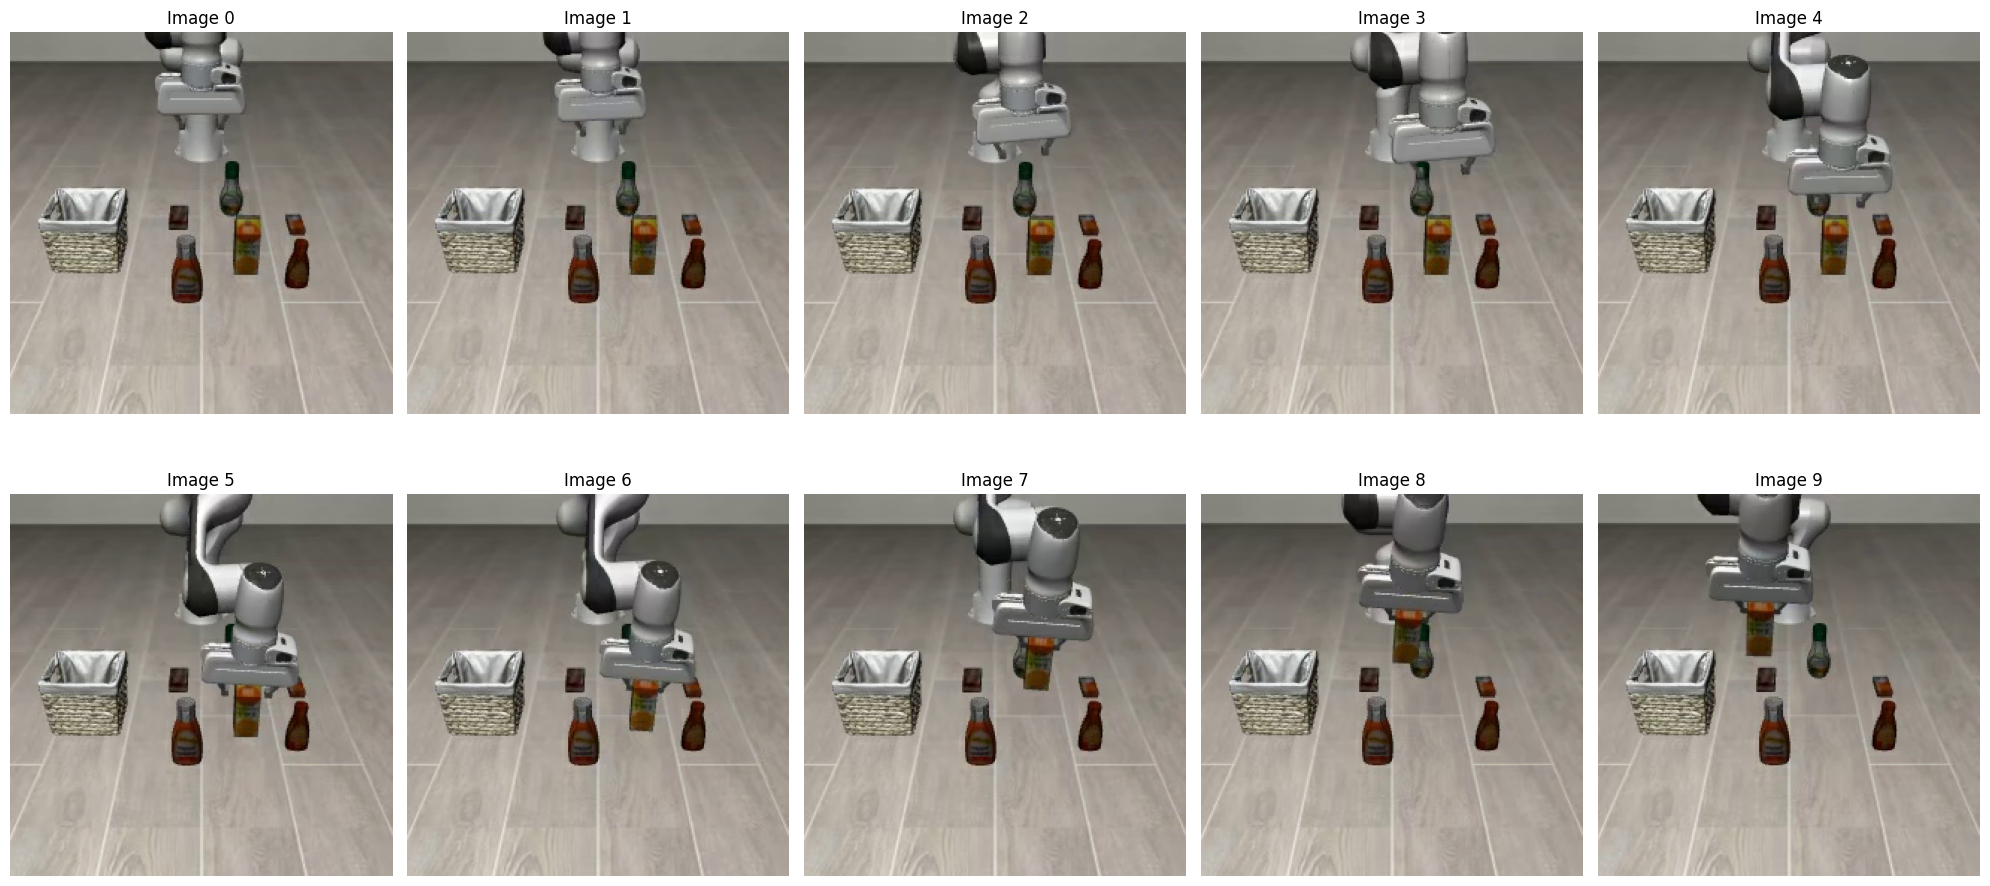

In [2]:
# visualize the dataset
# show img
import matplotlib.pyplot as plt

images_list = []

for i in range(100):
    if i % 10 == 0:
        resp = dataset[i]
        img = resp["video.image"][0]
        images_list.append(img)

fig, axs = plt.subplots(2, 5, figsize=(20, 10))
for i, ax in enumerate(axs.flat):
    ax.imshow(images_list[i])
    ax.axis("off")
    ax.set_title(f"Image {i}")
plt.tight_layout() # adjust the subplots to fit into the figure area.
plt.show()

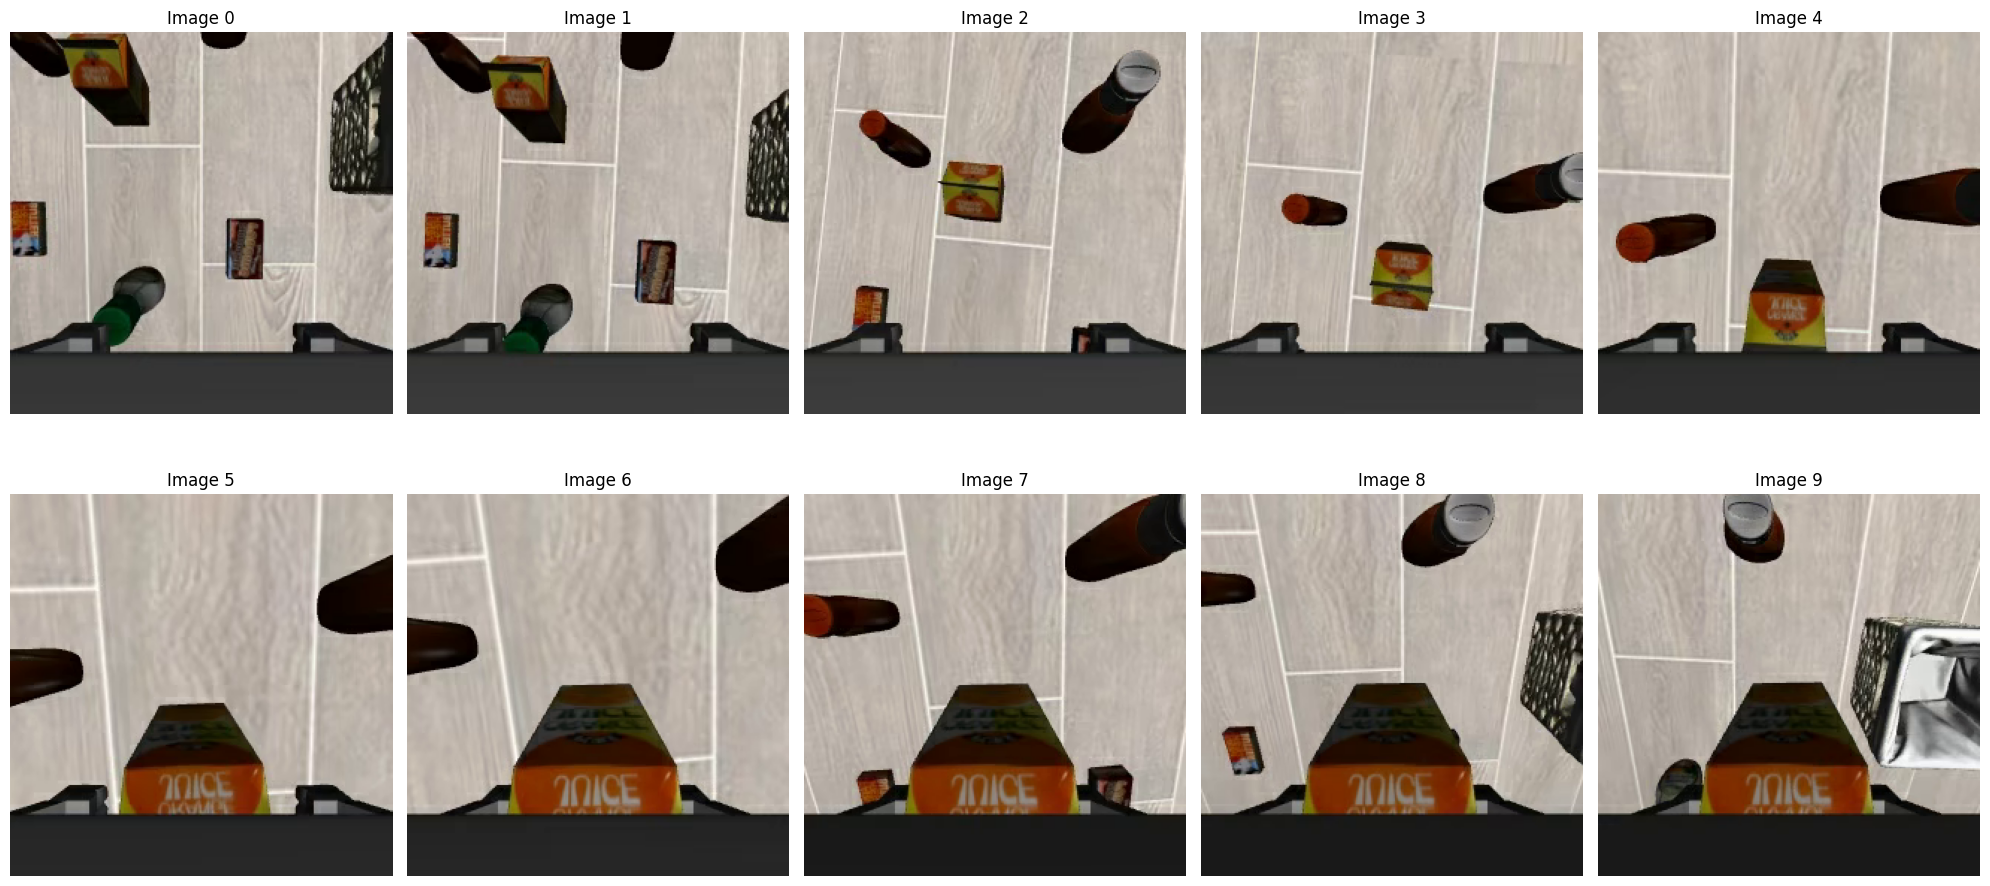

In [3]:
# visualize the dataset
# show img
import matplotlib.pyplot as plt

images_list = []

for i in range(100):
    if i % 10 == 0:
        resp = dataset[i]
        img = resp["video.wrist_image"][0]
        images_list.append(img)

fig, axs = plt.subplots(2, 5, figsize=(20, 10))
for i, ax in enumerate(axs.flat):
    ax.imshow(images_list[i])
    ax.axis("off")
    ax.set_title(f"Image {i}")
plt.tight_layout() # adjust the subplots to fit into the figure area.
plt.show()

## Step 2: Finetuning

Finetuning can be done by using our finetuning `scripts/gr00t_finetune.py`.


```bash
python /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/gr00t_finetune.py \
   --dataset-path /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/data/IPEC-COMMUNITY/libero_object_no_noops_lerobot \
   --num-gpus 4 \
   --output-dir /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/output/6_franka_libero_object_no_noops_lerobot_20000  \
   --max-steps 20000 \
   --data-config franka \
   --video-backend torchvision_av \
   --base-model-path /root/data/projects/embodiedai/grootn1/GR00T-N1-2B
```



## Step 3: Open-loop evaluation

Once the training is done, you can run the following command to visualize the finetuned policy. 

```bash
python /root/data/projects/embodiedai/grootn1/Isaac-GR00T/ff/eval_policy.py --plot \
   --embodiment_tag new_embodiment \
   --model_path /root/data/projects/embodiedai/grootn1/Isaac-GR00T/ff/output/gr00t-1/franka-checkpoints1/checkpoint-2000 \
   --data_config franka \
  --dataset_path /root/data/projects/embodiedai/grootn1/Isaac-GR00T/ff/data/IPEC-COMMUNITY/libero_object_no_noops_lerobot \
   --video_backend torchvision_av \
   --modality_keys x    y    z    roll    pitch    yaw    gripper 
```



This is a plot after training the policy for 7k steps.

![so100-7k-steps.png](../media/so100-7k-steps.png)


After training for more steps the plot will look significantly better.


TADA! You have successfully finetuned GR00T-N1 on a new embodiment.

## Deployment

For more details about deployment, please refer to the notebook: `5_policy_deployment.md`